**VIX in the one-factor Bergomi model**

# Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
from bergomi import OneFactorBergomi
import matplotlib as mpl
import numpy as np
import seaborn as sns
from utils import xi0_heston, relative_error
from scipy import integrate, stats

sns.set_theme(context="talk")
sns.set_style("whitegrid")
mpl.rcParams["figure.figsize"] = (8, 6)
SEED = 1234
COLORS = sns.color_palette("tab10")

# Single case

## VIX implied volatility

In [14]:
# simulation parameters
mats = {"1M": 1.0 / 12.0, "3M": 3.0 / 12.0, "6M": 6.0 / 12.0}

In [15]:
# model parameters
params = {"w": 2.0, "k": 0.5}

rho = -0.7
xi0 = lambda u: np.ones_like(u) * 0.235**2
# xi0 = lambda t: xi0_heston(t, shape="contango")

onebergomi = OneFactorBergomi(rho=rho, xi0=xi0, params=params)

In [16]:
onebergomi.w

2.0

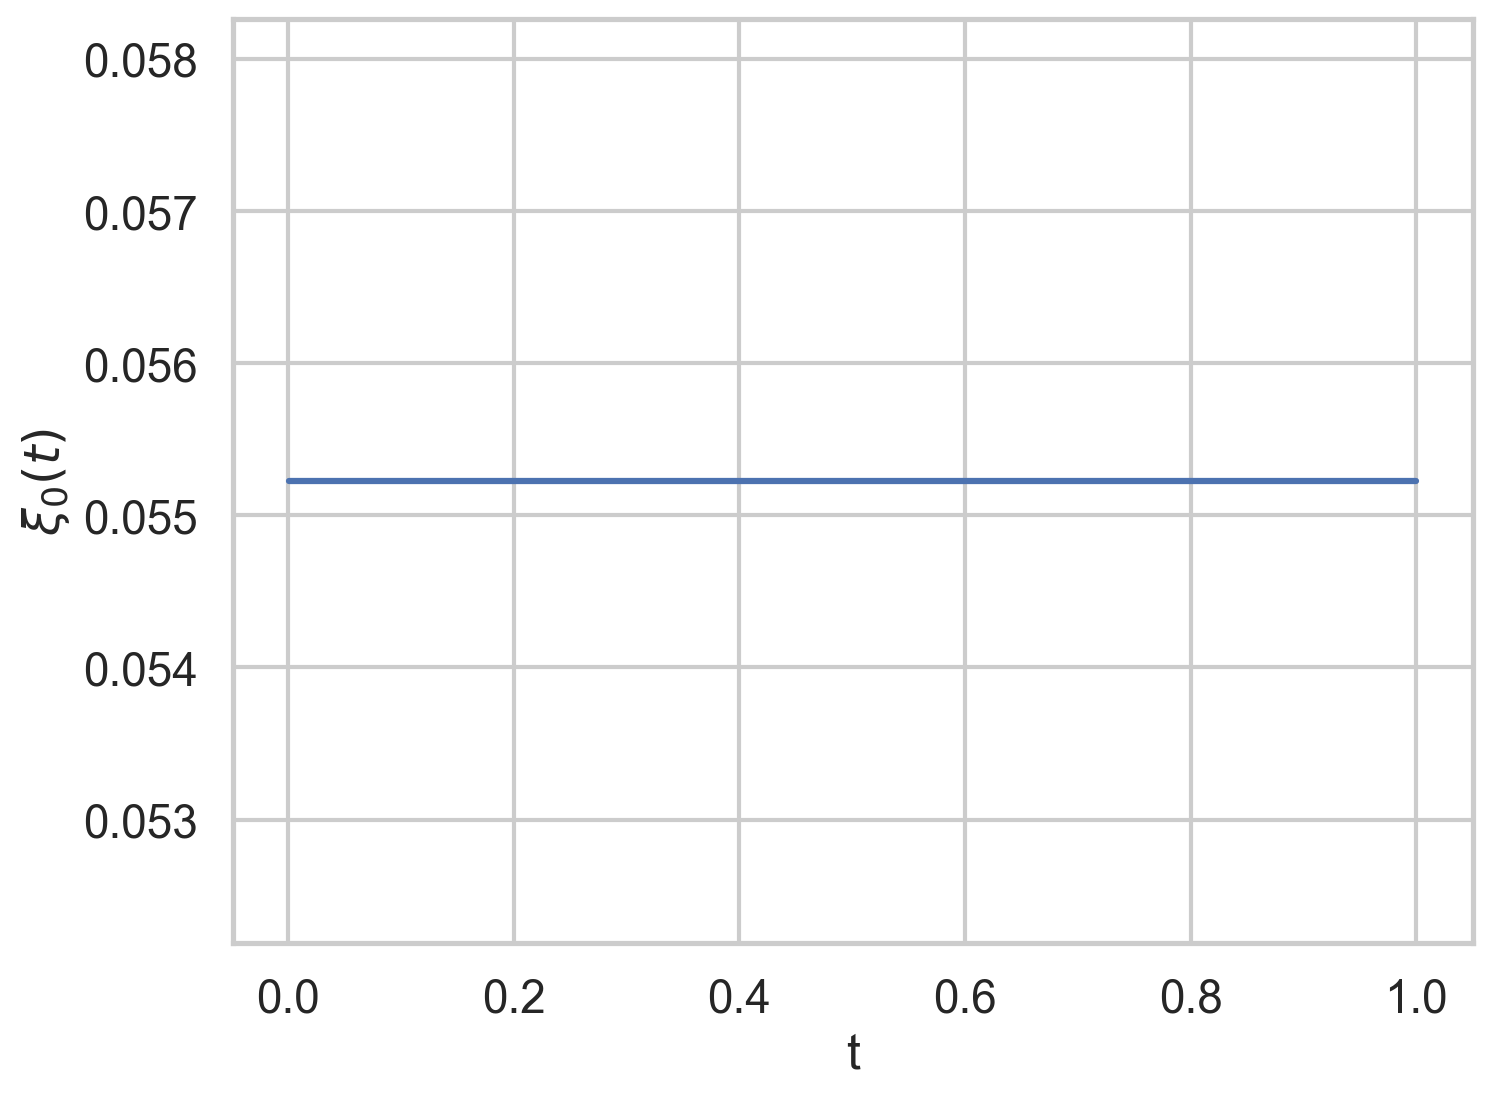

In [17]:
# plot xi0
ts = np.linspace(1e-3, 1.0, 101)
fig, ax = plt.subplots()
ax.plot(ts, onebergomi.xi0(ts))
ax.set_xlabel("t")
ax.set_ylabel(r"$\xi_0(t)$")
plt.show()

In [18]:
# log moneyness
ks = np.linspace(-0.1, 0.5, 11)

In [37]:
# VIX implied volatilities via quadrature
n_quad = 80
impvol_vix = {
    month: onebergomi.implied_vol_vix(k=ks, T=T, n_quad=n_quad)
    for month, T in mats.items()
}
impvol_vix

{'1M': array([0.95913559, 0.95936209, 0.95935076, 0.95910877, 0.95938057,
        0.95907241, 0.95933586, 0.95937043, 0.95931977, 0.95877916,
        0.95931083]),
 '3M': array([0.92112035, 0.92093796, 0.92109233, 0.92117995, 0.92119306,
        0.92116207, 0.92112035, 0.92109948, 0.92111617, 0.92115492,
        0.92113584]),
 '6M': array([0.86864054, 0.86847126, 0.86857498, 0.86861551, 0.86837351,
        0.86862028, 0.86844981, 0.86858213, 0.86844742, 0.86857617,
        0.86827338])}

In [20]:
# VIX implied vol from weak approximation
impvol_vix_approx = {
    month: onebergomi.implied_vol_vix_approx(k=ks, T=T, order=3)
    for month, T in mats.items()
}

In [21]:
impvol_vix_approx

{'1M': array([0.95935717, 0.95936552, 0.95937386, 0.95938221, 0.95939055,
        0.9593989 , 0.95940724, 0.95941529, 0.95942363, 0.95943198,
        0.95944032]),
 '3M': array([0.92122525, 0.921233  , 0.92124134, 0.92124909, 0.92125684,
        0.92126518, 0.92127293, 0.92128128, 0.92128903, 0.92129737,
        0.92130512]),
 '6M': array([0.8687374 , 0.86874515, 0.8687523 , 0.86876005, 0.8687672 ,
        0.86877495, 0.8687827 , 0.86878985, 0.8687976 , 0.86880535,
        0.8688125 ])}

In [22]:
# VIX implied vol from expansion formula
impvol_vix_expansion = {
    month: onebergomi.implied_vol_vix_expansion(k=ks, T=T, order=1)
    for month, T in mats.items()
}

In [23]:
impvol_vix_expansion

{'1M': array([0.95936245, 0.95937078, 0.95937911, 0.95938744, 0.95939577,
        0.95940409, 0.95941242, 0.95942075, 0.95942908, 0.9594374 ,
        0.95944573]),
 '3M': array([0.92123929, 0.92124728, 0.92125528, 0.92126328, 0.92127127,
        0.92127927, 0.92128727, 0.92129527, 0.92130326, 0.92131126,
        0.92131926]),
 '6M': array([0.86876104, 0.86876858, 0.86877612, 0.86878367, 0.86879121,
        0.86879875, 0.86880629, 0.86881383, 0.86882138, 0.86882892,
        0.86883646])}

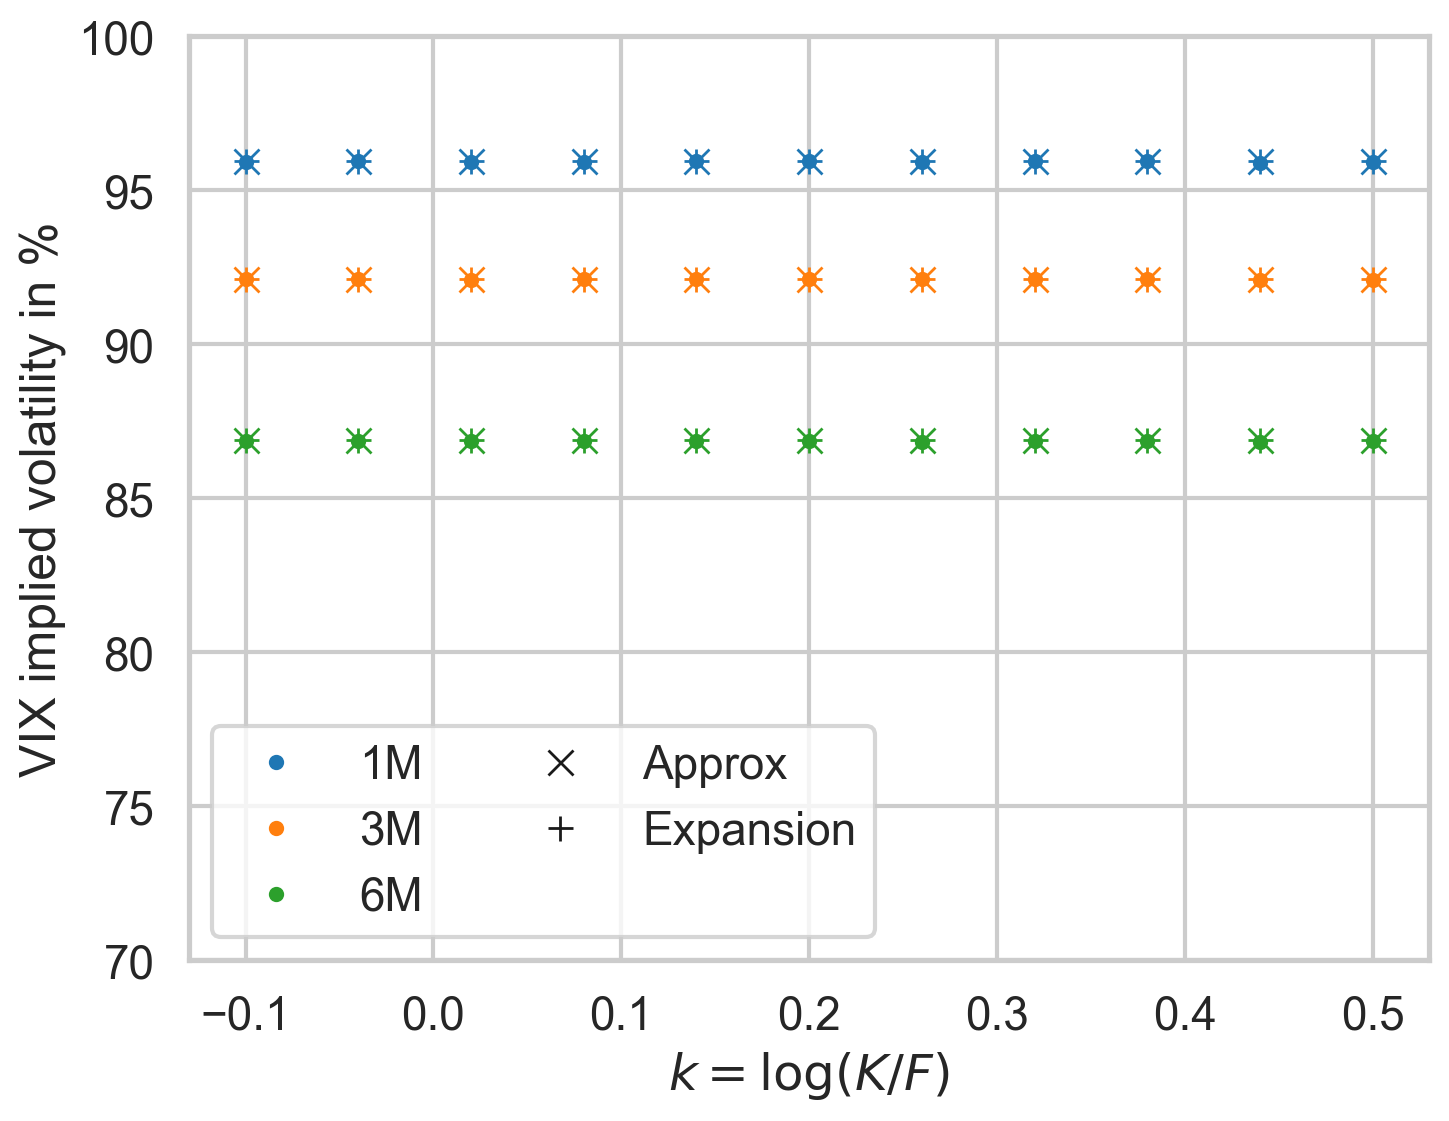

In [24]:
fig, ax = plt.subplots()
for i, month in enumerate(mats.keys()):
    ax.plot(ks, 100 * impvol_vix[month], ".", color=COLORS[i], label=f"{month}")
    ax.plot(ks, 100 * impvol_vix_approx[month], "x", color=COLORS[i])
    ax.plot(ks, 100 * impvol_vix_expansion[month], "+", color=COLORS[i])
ax.plot([], [], "kx", label="Approx")
ax.plot([], [], "k+", label="Expansion")
ax.set_xlabel(r"$k=\log(K/F)$")
ax.set_ylabel("VIX implied volatility in %")
ax.legend(loc="best", ncol=2)
ax.set_ylim(70, 100)
plt.show()

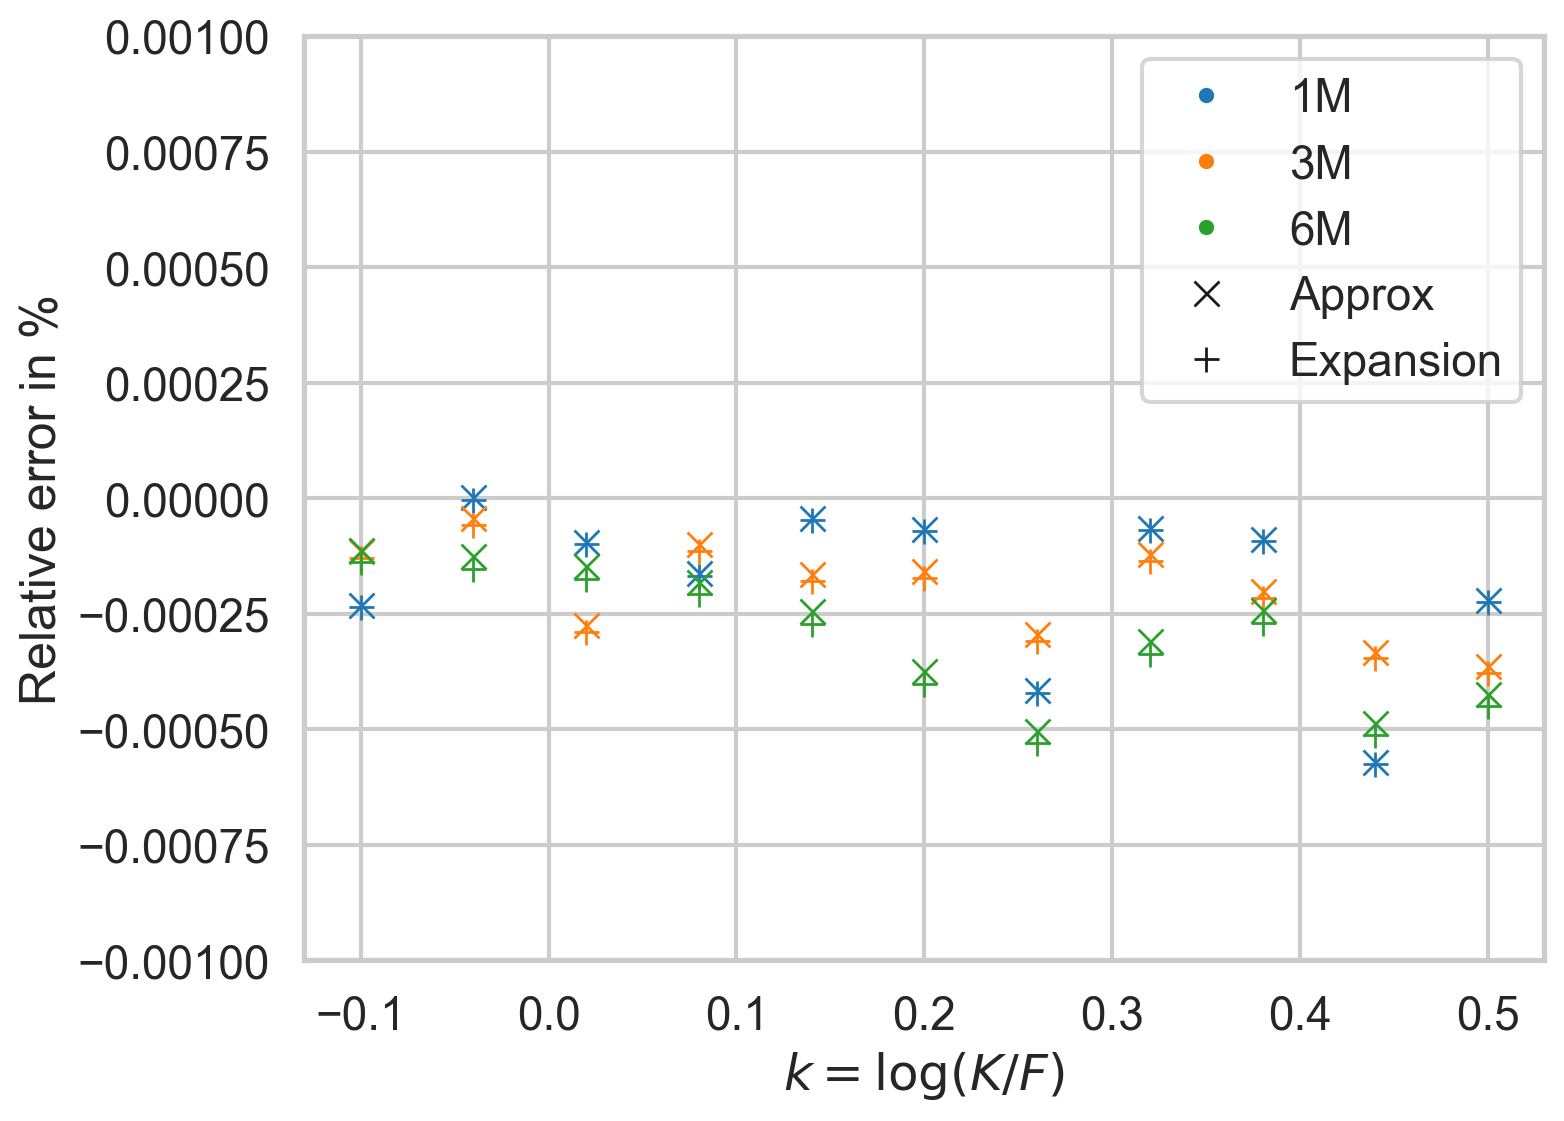

In [25]:
# relative errors
rel_error_approx = [
    relative_error(impvol_vix_approx[month], impvol_vix[month]) for month in mats
]
rel_error_expansion = [
    relative_error(impvol_vix_expansion[month], impvol_vix[month]) for month in mats
]

fig, ax = plt.subplots()
for i, month in enumerate(mats.keys()):
    ax.plot(ks, rel_error_approx[i], "x", color=COLORS[i])
    ax.plot(ks, rel_error_expansion[i], "+", color=COLORS[i])
    ax.plot([], [], ".", color=COLORS[i], label=f"{month}")
ax.plot([], [], "kx", label="Approx")
ax.plot([], [], "k+", label="Expansion")
ax.set_xlabel(r"$k=\log(K/F)$")
ax.set_ylabel("Relative error in %")
ax.legend(loc="best")
ax.set_ylim(-1e-3, 1e-3)
plt.show()

# Mixed case

In [32]:
params = {"w": 2.0, "k": 0.5}

rho = -0.7
xi0 = lambda u: np.ones_like(u) * 0.235**2
# xi0 = lambda t: xi0_heston(t, shape="contango")

onebergomi = OneFactorBergomi(rho=rho, xi0=xi0, params=params)

lbd = 0.3
w_2 = 0.3
ks = ks = np.linspace(-0.1, 0.4, 11)

In [33]:
# VIX implied volatilities
n_quad = 80
impvol_vix_mixed = {
    month: onebergomi.implied_vol_vix(k=ks, T=T, n_quad=n_quad, lbd=lbd, w_2=w_2)
    for month, T in mats.items()
}

In [34]:
# Gauss quadrature
# check for higher-order, is the integration range really correct? B seems different.
impvol_vix_mixed_approx = {
    month: np.asarray(
        onebergomi.implied_vol_vix_approx_mixed(
            lbd=lbd, volvol_2=w_2, k=ks, T=T, order=3, n_quad=80
        )
    )
    for month, T in mats.items()
}

In [38]:
# Lognormal approximation
impvol_vix_mixed_approx_lognorm = {
    month: np.asarray(
        onebergomi.implied_vol_vix_lognorm_approx_mixed(
            lbd=lbd, volvol_2=w_2, k=ks, T=T, order=0
        )
    )
    for month, T in mats.items()
}

In [40]:
# Shifted Lognormal approximation
impvol_vix_mixed_approx_slognorm = {
    month: np.asarray(
        onebergomi.implied_vol_vix_shifted_lognorm_approx_mixed(
            lbd=lbd, volvol_2=w_2, k=ks, T=T, order=0
        )
    )
    for month, T in mats.items()
}

m1_v: 0.23352939486736798, m1_y: 0.23352939486736798
m2_v: 0.05522461300599758, m2_y: 0.05522461300599758
m3_v: 0.013236543697605664, m3_y: 0.013236543697605664
m1_v: 0.23098648249405354, m1_y: 0.23098648249405354
m2_v: 0.055223929390940237, m2_y: 0.055223929390940237
m3_v: 0.013770116496958836, m3_y: 0.013770116496958836
m1_v: 0.22800629663497848, m1_y: 0.22800629663497848
m2_v: 0.055223095643077154, m2_y: 0.055223095643077154
m3_v: 0.014583759485573266, m3_y: 0.014583759485573266


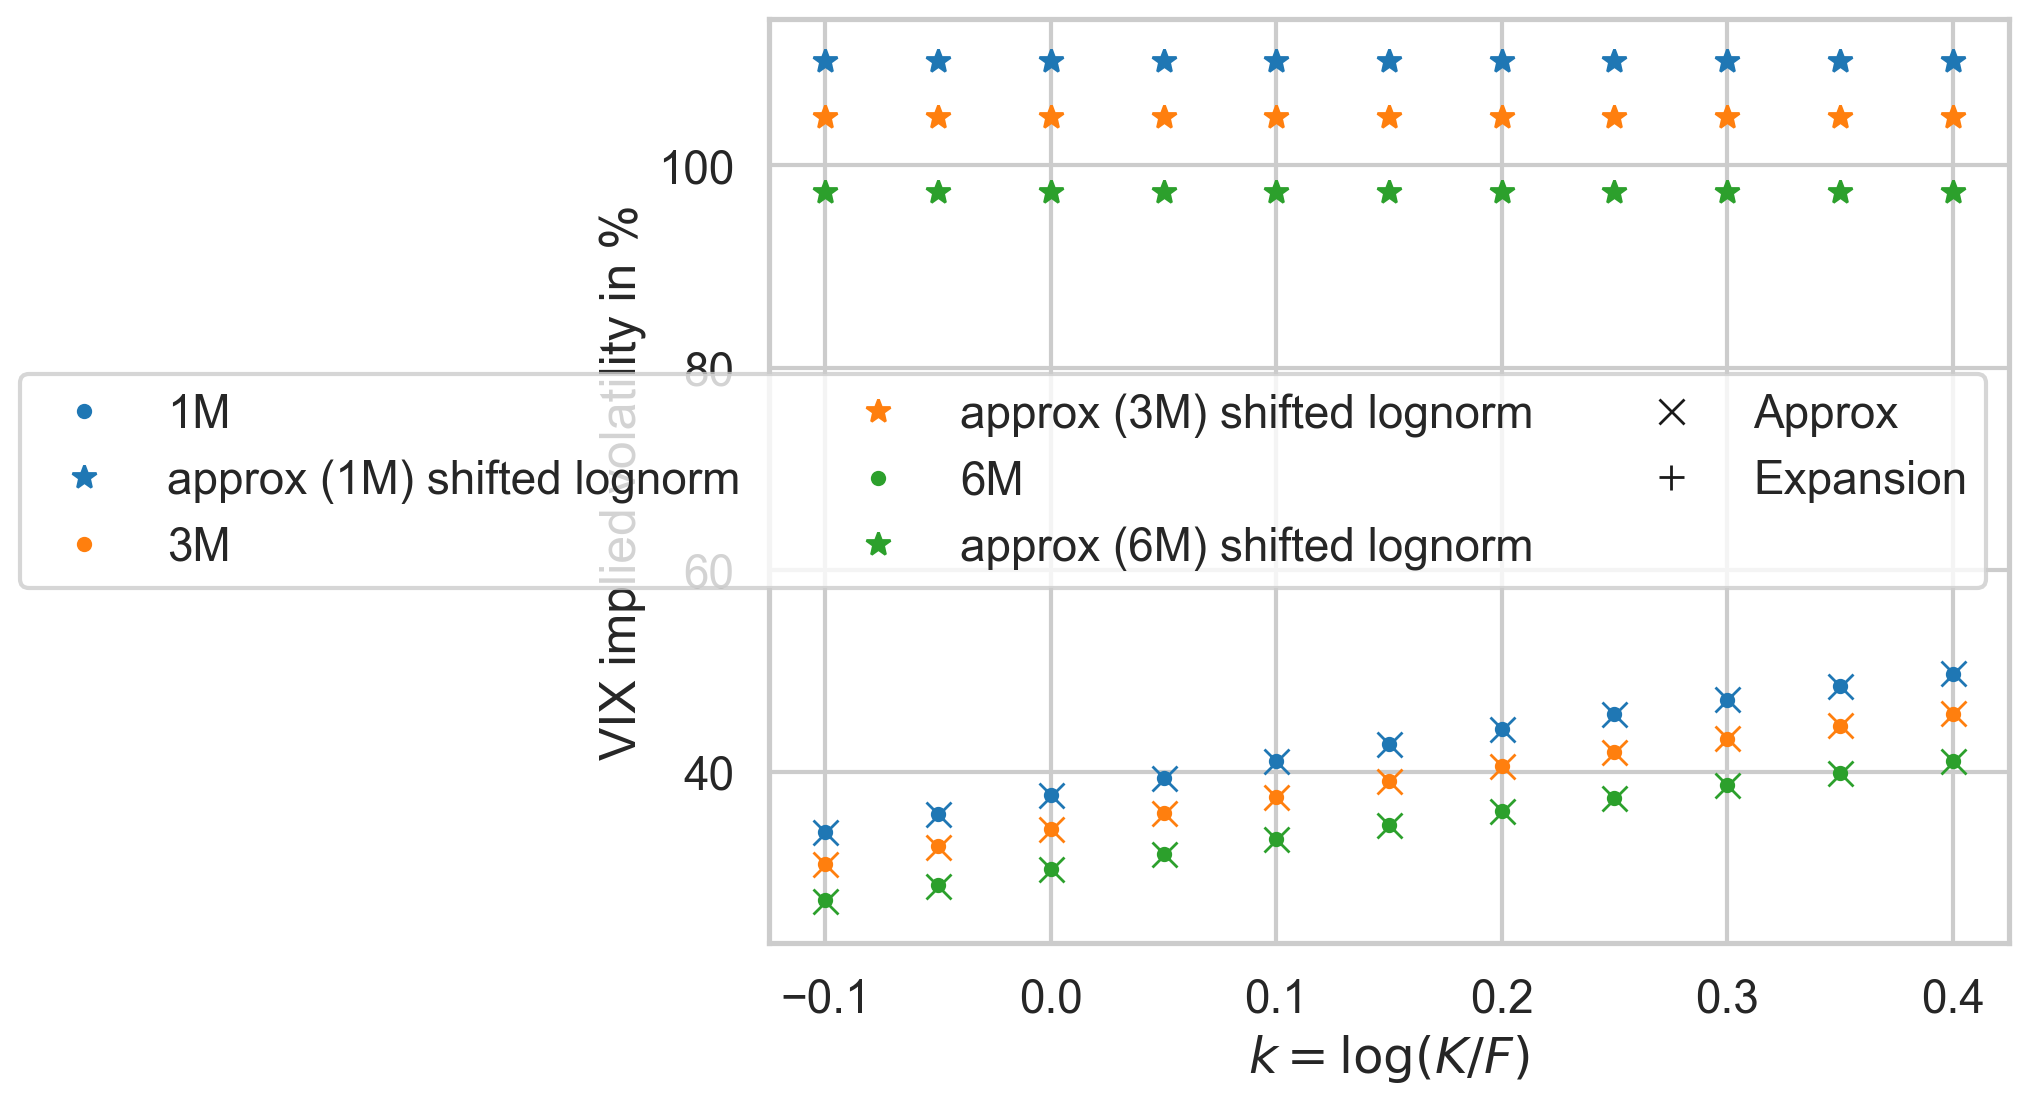

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
for i, month in enumerate(mats.keys()):
    ax.plot(
        ks,
        100 * impvol_vix_mixed[month],
        ".",
        color=COLORS[i],
        label=f"{month}",
    )
    ax.plot(
        ks,
        100 * impvol_vix_mixed_approx[month],
        "x",
        color=COLORS[i],
    )
    # ax.plot(
    #     ks,
    #     100 * impvol_vix_mixed_approx_lognorm[month],
    #     "v",
    #     color=COLORS[i],
    #     label=f"approx ({month}) lognorm",
    # )
    # ax.plot(
    #     ks,
    #     100 * impvol_vix_mixed_approx_slognorm[month],
    #     "*",
    #     color=COLORS[i],
    #     label=f"approx ({month}) shifted lognorm",
    # )
    # ax.plot(
    #     ks,
    #     100 * impvol_vix_mixed_approx_series[month],
    #     "*",
    #     color=COLORS[i],
    #     label=f"approx ({month}) series",
    # )
ax.plot([], [], "kx", label="Approx")
ax.plot([], [], "k+", label="Expansion")
ax.set_xlabel(r"$k=\log(K/F)$")
ax.set_ylabel("VIX implied volatility in %")
ax.legend(ncol=3)
# ax.set_ylim(10, 60)
plt.show()